# 07 — LoRA Fine-tuning (Config E)

Fine-tune LoRA r=8 trên UNet của `runwayml/stable-diffusion-inpainting`. Không dùng xformers.

```
project_root/
├── data/synthetic_occ/   ← output từ notebook 01
│   ├── x_gt/
│   ├── x_occ/
│   ├── masks/
│   └── metadata_synthetic_occ.csv
├── outputs/
│   ├── eval/             ← output từ notebook 02
│   └── lora_weights/r8/  ← output notebook này
└── notebooks/
```

**Chạy sau:** notebook 01, 02 &nbsp;|&nbsp; **Chạy trước:** 08_lora-inference.ipynb

In [1]:
# CELL 1 — Dependencies
import sys
!{sys.executable} -m pip install -q \
    "diffusers>=0.27.0" "peft>=0.8.0" "accelerate>=0.26.0" \
    "transformers>=4.36.0" "bitsandbytes>=0.41.0" \
    Pillow tqdm scikit-image lpips
print("Dependencies ready")

Dependencies ready


In [2]:
# CELL 2 — Config & Paths
import random, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths ──────────────────────────────────────────────
# Notebook nằm ở notebooks/ → project root là thư mục cha
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SYNTH_DIR = PROJECT_ROOT / "data" / "synthetic_occ"
GT_DIR    = SYNTH_DIR / "x_gt"
OCC_DIR   = SYNTH_DIR / "x_occ"
MASK_DIR  = SYNTH_DIR / "masks"
META_CSV  = SYNTH_DIR / "metadata_synthetic_occ.csv"
EVAL_CSV  = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"
LORA_OUT  = PROJECT_ROOT / "outputs" / "lora_weights" / "r8"
LORA_OUT.mkdir(parents=True, exist_ok=True)

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"

# ── LoRA config ────────────────────────────────────────
LORA_RANK    = 8
LORA_ALPHA   = 8
LORA_DROPOUT = 0.05

# ── Training hyperparameters ───────────────────────────
LEARNING_RATE       = 1e-4
MAX_TRAIN_STEPS     = 2000
TRAIN_BATCH_SIZE    = 2
GRAD_ACCUM_STEPS    = 4      # effective batch = 8
LR_WARMUP_STEPS     = 200
SNR_GAMMA           = 5.0
NOISE_OFFSET        = 0.1
CHECKPOINTING_STEPS = 500
VALIDATION_STEPS    = 250
VAL_SIZE            = 50
RESOLUTION          = 512
EARLY_STOP_PATIENCE = 6

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

assert SYNTH_DIR.exists(), f"Dataset không tìm thấy: {SYNTH_DIR}\n→ Chạy notebook 01 trước"
assert META_CSV.exists(),  f"Metadata không tìm thấy: {META_CSV}"
print(f"Device       : {DEVICE}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset      : {SYNTH_DIR}  ({len(list(GT_DIR.iterdir())):,} ảnh)")
print(f"LoRA output  : {LORA_OUT}")
print(f"LoRA r={LORA_RANK}, alpha={LORA_ALPHA}, steps={MAX_TRAIN_STEPS}")

Device       : cuda
Project root : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus
Dataset      : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\data\synthetic_occ  (11,254 ảnh)
LoRA output  : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8
LoRA r=8, alpha=8, steps=2000


In [3]:
# CELL 3 — Train / Val Split
meta = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()

if EVAL_CSV.exists():
    test_stems = set(pd.read_csv(EVAL_CSV)["stem"].tolist())
    print(f"Test stems từ eval CSV: {len(test_stems)}")
else:
    test_stems = set(meta.sample(200, random_state=SEED)["stem"].tolist())
    print(f"⚠  Eval CSV không tìm thấy — reproduced split: {len(test_stems)} stems")

non_test   = meta[~meta["stem"].isin(test_stems)].reset_index(drop=True)
val_meta   = non_test.sample(min(VAL_SIZE, len(non_test)), random_state=SEED).reset_index(drop=True)
train_meta = non_test[~non_test["stem"].isin(set(val_meta["stem"]))].reset_index(drop=True)

if len(train_meta) < 100:
    print("⚠  Training set < 100 ảnh → giảm MAX_TRAIN_STEPS xuống 1000")
    MAX_TRAIN_STEPS = 1000

print(f"Train: {len(train_meta):,}  |  Val: {len(val_meta):,}  |  Test: {len(test_stems):,}")

⚠  Eval CSV không tìm thấy — reproduced split: 200 stems
Train: 11,004  |  Val: 50  |  Test: 200


In [6]:
# CELL 4 — Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
from pathlib import Path

class CarInpaintDataset(Dataset):
    def __init__(self, meta_df, gt_dir, occ_dir, mask_dir, tokenizer, size=512, augment=True):
        self.meta      = meta_df.reset_index(drop=True)
        self.gt_dir    = Path(gt_dir)
        self.occ_dir   = Path(occ_dir)
        self.mask_dir  = Path(mask_dir)
        self.tokenizer = tokenizer
        self.size      = size
        self.augment   = augment
        self.normalize = transforms.Normalize([0.5]*3, [0.5]*3)
        self.to_tensor = transforms.ToTensor()
        self.jitter    = transforms.ColorJitter(
            brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02
        ) if augment else None

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row  = self.meta.iloc[idx]
        gt   = Image.open(self.gt_dir   / row["x_gt"]).convert("RGB").resize((self.size, self.size))
        occ  = Image.open(self.occ_dir  / row["x_occ"]).convert("RGB").resize((self.size, self.size))
        mask = Image.open(self.mask_dir / f"{row['stem']}.png").convert("L").resize(
            (self.size, self.size), resample=Image.NEAREST
        )
        
        if self.augment and torch.rand(1).item() < 0.5:
            gt = TF.hflip(gt); occ = TF.hflip(occ); mask = TF.hflip(mask)
            
        if self.jitter:
            # Sửa lỗi: Lấy đúng 5 biến (fn_idx, brightness, contrast, saturation, hue)
            fn_idx, b, c, s, h = self.jitter.get_params(
                self.jitter.brightness, self.jitter.contrast,
                self.jitter.saturation, self.jitter.hue
            )
            
            # Ép kiểu float() để đảm bảo thư viện PIL không bị lỗi với PyTorch Tensor
            for fn, val in [
                (TF.adjust_brightness, float(b)), 
                (TF.adjust_contrast, float(c)),
                (TF.adjust_saturation, float(s)), 
                (TF.adjust_hue, float(h)),
            ]:
                gt = fn(gt, val); occ = fn(occ, val)

        gt_t     = self.normalize(self.to_tensor(gt))
        mask_t   = (self.to_tensor(mask) > 0.5).float()
        masked_t = self.normalize(self.to_tensor(occ)) * (1.0 - mask_t)

        enc = self.tokenizer(
            "a car, realistic, high quality, detailed",
            padding="max_length", max_length=self.tokenizer.model_max_length,
            truncation=True, return_tensors="pt",
        )
        return {
            "pixel_values"   : gt_t,
            "masked_image"   : masked_t,
            "mask"           : mask_t,
            "input_ids"      : enc.input_ids[0],
            "occlusion_ratio": float(row.get("occlusion_ratio", 0.0)),
        }

print("CarInpaintDataset defined.")

CarInpaintDataset defined.


In [7]:
# CELL 5 — Load Models + Inject LoRA r=8  (không dùng xformers)
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from transformers import CLIPTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model

tokenizer    = CLIPTokenizer.from_pretrained(SD_MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(SD_MODEL_ID, subfolder="text_encoder")
vae          = AutoencoderKL.from_pretrained(SD_MODEL_ID, subfolder="vae")
unet         = UNet2DConditionModel.from_pretrained(SD_MODEL_ID, subfolder="unet")
noise_sched  = DDPMScheduler.from_pretrained(SD_MODEL_ID, subfolder="scheduler")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

lora_config = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_ALPHA,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=LORA_DROPOUT, bias="none", init_lora_weights="gaussian",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

unet.enable_gradient_checkpointing()
#unet.enable_attention_slicing("auto")  # không dùng xformers

unet.to(DEVICE, dtype=torch.float32)   # float32 để LoRA train ổn định
vae.to(DEVICE,  dtype=DTYPE)
text_encoder.to(DEVICE, dtype=DTYPE)

train_dataset = CarInpaintDataset(train_meta, GT_DIR, OCC_DIR, MASK_DIR, tokenizer, augment=True)
val_dataset   = CarInpaintDataset(val_meta,   GT_DIR, OCC_DIR, MASK_DIR, tokenizer, augment=False)
train_loader  = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE,
                           shuffle=True,  num_workers=0, pin_memory=(DEVICE=="cuda"), drop_last=True)
val_loader    = DataLoader(val_dataset,   batch_size=TRAIN_BATCH_SIZE,
                           shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))

# Sanity check
sample_batch = next(iter(train_loader))
print(f"pixel_values: {sample_batch['pixel_values'].shape}  "
      f"mask: {sample_batch['mask'].shape}  "
      f"input_ids: {sample_batch['input_ids'].shape}")
print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


trainable params: 1,594,368 || all params: 861,129,732 || trainable%: 0.1851
pixel_values: torch.Size([2, 3, 512, 512])  mask: torch.Size([2, 1, 512, 512])  input_ids: torch.Size([2, 77])
Train: 5502 batches | Val: 25 batches


In [8]:
# CELL 6 — Training Loop
from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

trainable_params_list = [p for p in unet.parameters() if p.requires_grad]
optimizer  = torch.optim.AdamW(trainable_params_list,
                               lr=LEARNING_RATE, betas=(0.9,0.999), weight_decay=1e-2, eps=1e-8)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=LR_WARMUP_STEPS, num_training_steps=MAX_TRAIN_STEPS)
scaler = torch.amp.GradScaler('cuda') if DEVICE == "cuda" else None
alphas_cumprod = noise_sched.alphas_cumprod.to(DEVICE)


def compute_snr(t):
    a = alphas_cumprod[t].sqrt()
    b = (1.0 - alphas_cumprod[t]).sqrt()
    return (a / b) ** 2


def forward_pass(batch):
    gt_pv  = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
    mask   = batch["mask"].to(DEVICE, dtype=DTYPE)
    masked = batch["masked_image"].to(DEVICE, dtype=DTYPE)
    ids    = batch["input_ids"].to(DEVICE)
    with torch.no_grad():
        latents        = vae.encode(gt_pv).latent_dist.sample()  * vae.config.scaling_factor
        masked_latents = vae.encode(masked).latent_dist.sample() * vae.config.scaling_factor
        mask_latent    = F.interpolate(mask, size=latents.shape[-2:], mode="nearest")
        encoder_hidden = text_encoder(ids)[0]
    noise = torch.randn_like(latents)
    if NOISE_OFFSET > 0:
        noise = noise + NOISE_OFFSET * torch.randn(
            latents.shape[0], latents.shape[1], 1, 1, device=DEVICE, dtype=DTYPE)
    bsz = latents.shape[0]
    t   = torch.randint(0, noise_sched.config.num_train_timesteps, (bsz,), device=DEVICE, dtype=torch.long)
    noisy_latents = noise_sched.add_noise(latents, noise, t)
    model_input   = torch.cat([noisy_latents, mask_latent, masked_latents], dim=1)
    noise_pred    = unet(model_input.float(), t, encoder_hidden_states=encoder_hidden.float()).sample
    snr    = compute_snr(t).float()
    weight = torch.clamp(snr, max=SNR_GAMMA) / snr if SNR_GAMMA > 0 else torch.ones(bsz, device=DEVICE)
    diff   = (noise_pred - noise.float()) ** 2
    loss   = (( diff * mask_latent ).mean(dim=[1,2,3]) * weight).mean()
    return loss


global_step = 0; running_loss = 0.0
train_losses = []; val_losses = []
best_val_loss = float("inf"); early_stop_counter = 0
saved_checkpoints = []

unet.train()
data_iter = iter(train_loader)
optimizer.zero_grad()
t0_train = time.time()
pbar = tqdm(range(MAX_TRAIN_STEPS), desc=f"LoRA r={LORA_RANK}", dynamic_ncols=True)

for step in pbar:
    accum_loss = 0.0
    for _ in range(GRAD_ACCUM_STEPS):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader); batch = next(data_iter)
        if DEVICE == "cuda" and scaler is not None:
            with torch.amp.autocast('cuda'):
                loss = forward_pass(batch) / GRAD_ACCUM_STEPS
            scaler.scale(loss).backward()
        else:
            loss = forward_pass(batch) / GRAD_ACCUM_STEPS
            loss.backward()
        accum_loss += loss.item()

    if DEVICE == "cuda" and scaler is not None:
        scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(trainable_params_list, max_norm=1.0)
    if DEVICE == "cuda" and scaler is not None:
        scaler.step(optimizer); scaler.update()
    else:
        optimizer.step()
    lr_scheduler.step(); optimizer.zero_grad()
    global_step += 1; running_loss += accum_loss * GRAD_ACCUM_STEPS

    if global_step % 50 == 0:
        avg = running_loss / 50
        train_losses.append({"step": global_step, "loss": avg})
        pbar.set_postfix({"loss": f"{avg:.4f}", "lr": f"{lr_scheduler.get_last_lr()[0]:.2e}"})
        running_loss = 0.0

    if global_step % CHECKPOINTING_STEPS == 0:
        ckpt_dir = LORA_OUT / f"checkpoint-{global_step}"
        unet.save_pretrained(str(ckpt_dir))
        saved_checkpoints.append(str(ckpt_dir))
        print(f"\n  [Step {global_step}] Checkpoint → {ckpt_dir.name}")

    if global_step % VALIDATION_STEPS == 0:
        unet.eval()
        val_total = 0.0
        with torch.no_grad():
            for vb in val_loader:
                with torch.amp.autocast('cuda') if DEVICE=="cuda" else torch.no_grad():
                    val_total += forward_pass(vb).item()
        avg_val = val_total / len(val_loader)
        val_losses.append({"step": global_step, "val_loss": avg_val})
        elapsed = (time.time() - t0_train) / 60
        print(f"  [Step {global_step:4d}] val_loss={avg_val:.4f} | {elapsed:.1f} min")
        if avg_val < best_val_loss:
            best_val_loss = avg_val; early_stop_counter = 0
            unet.save_pretrained(str(LORA_OUT / "best"))
            print(f"  ✓ Best checkpoint (val={best_val_loss:.4f})")
        else:
            early_stop_counter += 1
            if early_stop_counter >= EARLY_STOP_PATIENCE:
                print("Early stopping."); break
        unet.train()

unet.save_pretrained(str(LORA_OUT / "final"))
total_time = (time.time() - t0_train) / 60
print(f"\nDone: {global_step} steps, {total_time:.1f} min, best_val={best_val_loss:.4f}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_11308\2510486009.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None
LoRA r=8:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_11308\2510486009.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
LoRA r=8:  12%|█▏        | 249/2000 [18:25<2:10:38,  4.48s/it, loss=0.0659, lr=9.98e-05]C:\Users\Admin\AppData\Local\Temp\ipykernel_11308\2510486009.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast() if DEVICE=="cuda" else torch.no_grad():
LoRA r=8:  12%|█▎        | 250/2000 [18:43<4:46:23,  9.82s/it, loss=0.0659, lr=9.98e-05]

  [Step  250] val_loss=0.0144 | 18.7 min
  ✓ Best checkpoint (val=0.0144)


LoRA r=8:  25%|██▍       | 499/2000 [37:22<1:51:53,  4.47s/it, loss=0.0647, lr=9.33e-05]


  [Step 500] Checkpoint → checkpoint-500


LoRA r=8:  25%|██▌       | 500/2000 [37:39<3:56:23,  9.46s/it, loss=0.0647, lr=9.33e-05]

...

  [Step 1750] val_loss=0.0131 | 131.4 min


LoRA r=8: 100%|█████████▉| 1999/2000 [2:29:23<00:04,  4.42s/it, loss=0.0673, lr=0.00e+00]


  [Step 2000] Checkpoint → checkpoint-2000


LoRA r=8: 100%|██████████| 2000/2000 [2:29:41<00:00,  4.49s/it, loss=0.0673, lr=0.00e+00]

  [Step 2000] val_loss=0.0165 | 149.7 min

Done: 2000 steps, 149.7 min, best_val=0.0116


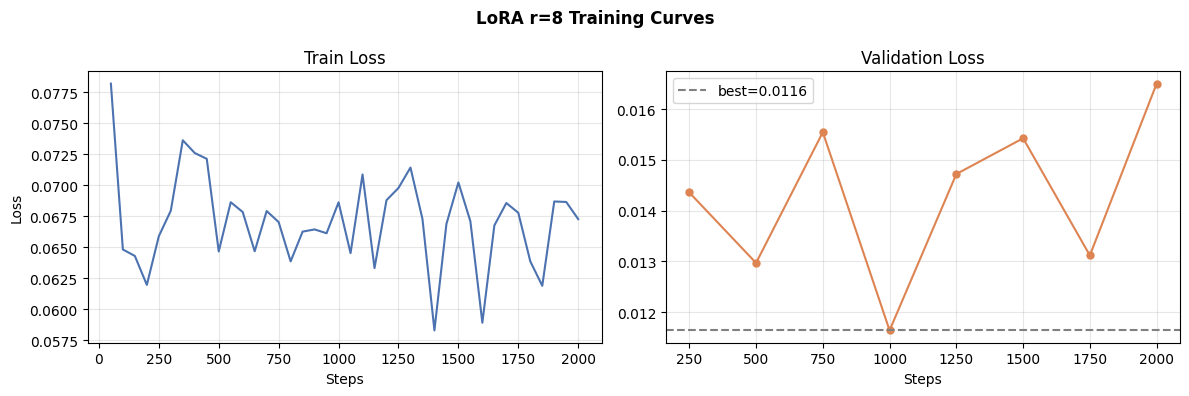

Saved training_config.json + curves → D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8


In [9]:
# CELL 7 — Loss Curves + Save Config
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"LoRA r={LORA_RANK} Training Curves", fontweight="bold")
if train_losses:
    df_tr = pd.DataFrame(train_losses)
    axes[0].plot(df_tr["step"], df_tr["loss"], color="#4C72B0")
    axes[0].set(title="Train Loss", xlabel="Steps", ylabel="Loss"); axes[0].grid(alpha=0.3)
if val_losses:
    df_val = pd.DataFrame(val_losses)
    axes[1].plot(df_val["step"], df_val["val_loss"], color="#DD8452", marker="o", markersize=5)
    axes[1].axhline(best_val_loss, linestyle="--", color="gray", label=f"best={best_val_loss:.4f}")
    axes[1].set(title="Validation Loss", xlabel="Steps"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(LORA_OUT / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

cfg = {
    "base_model": SD_MODEL_ID, "lora_rank": LORA_RANK, "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT, "target_modules": ["to_q","to_k","to_v","to_out.0"],
    "max_steps": MAX_TRAIN_STEPS, "actual_steps": global_step,
    "learning_rate": LEARNING_RATE, "batch_size": TRAIN_BATCH_SIZE,
    "grad_accum": GRAD_ACCUM_STEPS, "snr_gamma": SNR_GAMMA, "noise_offset": NOISE_OFFSET,
    "best_val_loss": best_val_loss, "train_samples": len(train_meta),
    "val_samples": len(val_meta), "seed": SEED, "total_time_min": round(total_time, 1),
    "best_checkpoint": str(LORA_OUT / "best"), "xformers": False, "attention_slicing": True,
}
(LORA_OUT / "training_config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")
if train_losses: pd.DataFrame(train_losses).to_csv(LORA_OUT / "train_losses.csv", index=False)
if val_losses:   pd.DataFrame(val_losses).to_csv(LORA_OUT / "val_losses.csv", index=False)
print(f"Saved training_config.json + curves → {LORA_OUT}")

text_encoder\model.safetensors not found
Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  50%|█████     | 3/6 [00:08<00:06,  2.19s/it]An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:27<00:00, 8.81MB/s] 
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` 

Loading model from: c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\weights\v0.1\alex.pth


100%|██████████| 20/20 [01:59<00:00,  5.98s/it]


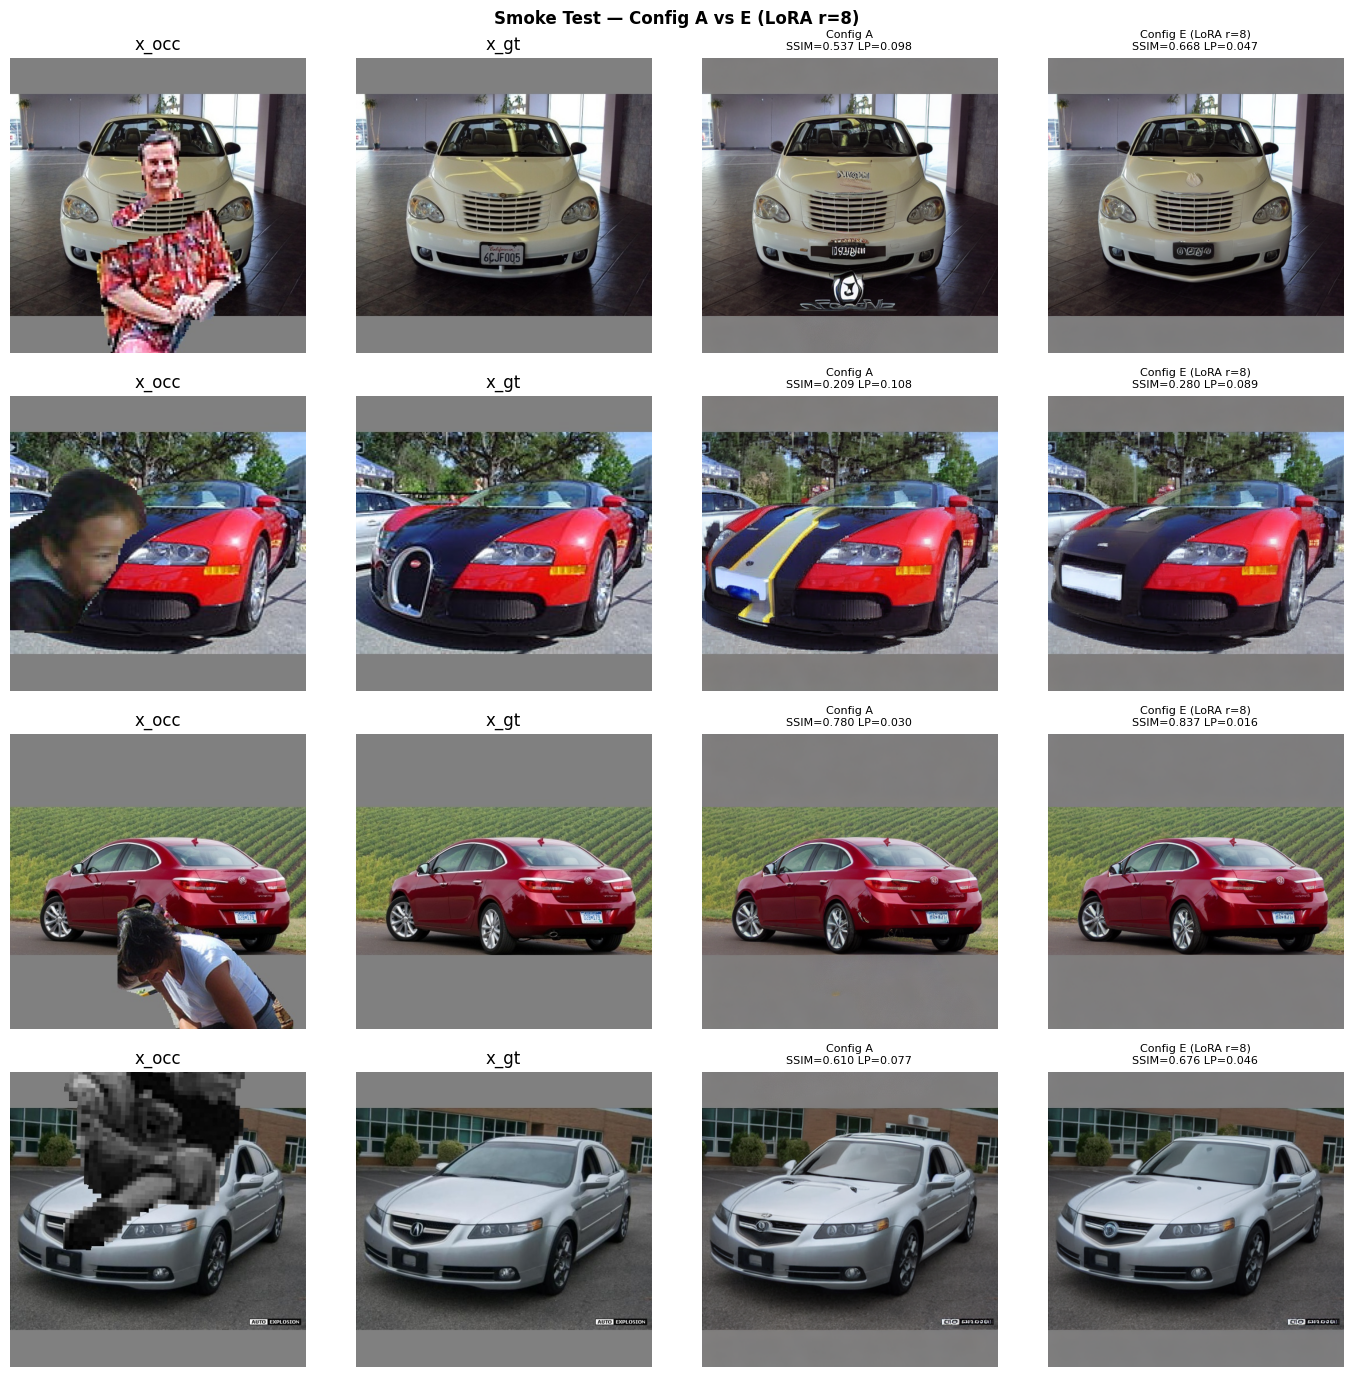

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8/smoke_test.png


In [12]:
    # CELL 8 — Smoke Test: Config A vs Config E
    from peft import PeftModel
    from diffusers import StableDiffusionInpaintPipeline
    from skimage.metrics import structural_similarity as ssim_fn
    import lpips as lpips_lib

    PROMPT = "a car, realistic, high quality, detailed"
    NEG_PROMPT = "blurry, distorted, artifacts"

    pipe_e = StableDiffusionInpaintPipeline.from_pretrained(
        SD_MODEL_ID, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False)
    pipe_e.unet = PeftModel.from_pretrained(pipe_e.unet, str(LORA_OUT / "best"))
    pipe_e.unet = pipe_e.unet.merge_and_unload()
    pipe_e = pipe_e.to(DEVICE)
    pipe_e.enable_attention_slicing("auto")

    pipe_a = StableDiffusionInpaintPipeline.from_pretrained(
        SD_MODEL_ID, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False
    ).to(DEVICE); pipe_a.enable_attention_slicing("auto")

    lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()

    def masked_ssim(gt, pred, m):
        _, smap = ssim_fn(gt/255., pred/255., channel_axis=2, data_range=1.0, full=True)
        return float(smap[m.astype(bool)].mean()) if m.sum() > 0 else float(smap.mean())

    def masked_lpips_val(gt, pred, m):
        mf = m.astype(np.float32)[..., None]
        gt_t = torch.from_numpy((gt*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
        pr_t = torch.from_numpy((pred*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
        with torch.no_grad(): return float(lpips_model(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())

    n_show = min(4, len(val_meta))
    rows   = val_meta.sample(n_show, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5*n_show))
    if n_show == 1: axes = np.expand_dims(axes, 0)
    fig.suptitle(f"Smoke Test — Config A vs E (LoRA r={LORA_RANK})", fontweight="bold")

    for i, row in rows.iterrows():
        occ = Image.open(OCC_DIR  / row["x_occ"]).convert("RGB").resize((512,512))
        msk = Image.open(MASK_DIR / f"{row['stem']}.png").convert("L").resize((512,512))
        gt  = Image.open(GT_DIR   / row["x_gt"]).convert("RGB").resize((512,512))
        gen = torch.Generator(device=DEVICE).manual_seed(SEED)
        out_a = pipe_a(prompt=PROMPT, negative_prompt=NEG_PROMPT, image=occ, mask_image=msk,
                    num_inference_steps=20, guidance_scale=7.5, generator=gen).images[0]
        out_e = pipe_e(prompt=PROMPT, negative_prompt=NEG_PROMPT, image=occ, mask_image=msk,
                    num_inference_steps=20, guidance_scale=7.5,
                    generator=torch.Generator(device=DEVICE).manual_seed(SEED)).images[0]
        gt_np = np.array(gt); a_np = np.array(out_a); e_np = np.array(out_e)
        mk01  = (np.array(msk) > 127).astype(np.uint8)
        axes[i,0].imshow(np.array(occ)); axes[i,0].set_title("x_occ")
        axes[i,1].imshow(gt_np);         axes[i,1].set_title("x_gt")
        axes[i,2].imshow(a_np);          axes[i,2].set_title(
            f"Config A\nSSIM={masked_ssim(gt_np,a_np,mk01):.3f} LP={masked_lpips_val(gt_np,a_np,mk01):.3f}", fontsize=8)
        axes[i,3].imshow(e_np);          axes[i,3].set_title(
            f"Config E (LoRA r={LORA_RANK})\nSSIM={masked_ssim(gt_np,e_np,mk01):.3f} LP={masked_lpips_val(gt_np,e_np,mk01):.3f}", fontsize=8)
        for ax in axes[i]: ax.axis("off")

    plt.tight_layout()
    plt.savefig(LORA_OUT / "smoke_test.png", dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {LORA_OUT}/smoke_test.png")

In [13]:
# CELL 9 — GPU Report
import subprocess
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM: {peak:.0f} MiB ({peak/1024:.2f} GiB)")
    try:
        print(subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"], stderr=subprocess.DEVNULL
        ).decode().strip())
    except Exception: pass
print(f"\nNotebook 07 complete — LoRA r={LORA_RANK}")
print(f"  Best val loss : {best_val_loss:.4f}")
print(f"  Training time : {total_time:.1f} min")
print(f"  Best ckpt     : {LORA_OUT}/best")
print(f"\n→ Tiếp theo: 08_lora-inference.ipynb")

Peak VRAM: 8491 MiB (8.29 GiB)
NVIDIA GeForce RTX 4050 Laptop GPU, 6141, 5910, 12

Notebook 07 complete — LoRA r=8
  Best val loss : 0.0116
  Training time : 149.7 min
  Best ckpt     : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8/best

→ Tiếp theo: 08_lora-inference.ipynb
